# Project - 1
## Time series & category charts
1. Plot sales over time (line charts) and monthly/quarterly aggregation.
2. Use bar charts to compare categories and pie charts for share.
3. Save charts to PNG and export a short summary.
4. Discuss chart choice and label/legend/axis formatting.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

### Data loading & validation

In [7]:
filepath = "sales_data.csv"
data = pd.read_csv(filepath)
data.head(3)

,Date,Sales,Category
0,2023-01-01,191.08,Electronics
1,2023-01-02,198.69,Electronics
2,2023-01-03,234.73,Electronics


In [8]:
data.isnull().sum()

Date         0
Sales       15
Category     0
dtype: int64

In [10]:
data.duplicated().sum()

0

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2193 non-null   datetime64[ns]
 1   Sales     2178 non-null   float64       
 2   Category  2193 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 51.5+ KB


In [12]:
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

In [18]:
data["Category"] = data["Category"].astype(str).str.strip()

In [19]:
data["Sales"] = pd.to_numeric(data["Sales"], errors="coerce")

### Time series charts

Why a line chart?
Line charts are the standard choice for time series because they visually preserve the ORDER and CONTINUITY of observations along the x-axis. The eye can immediately trace trend direction, seasonality, and volatility properties that are much harder to read from bars or points alone, especially at daily granularity with many data points.

#### Daily sales

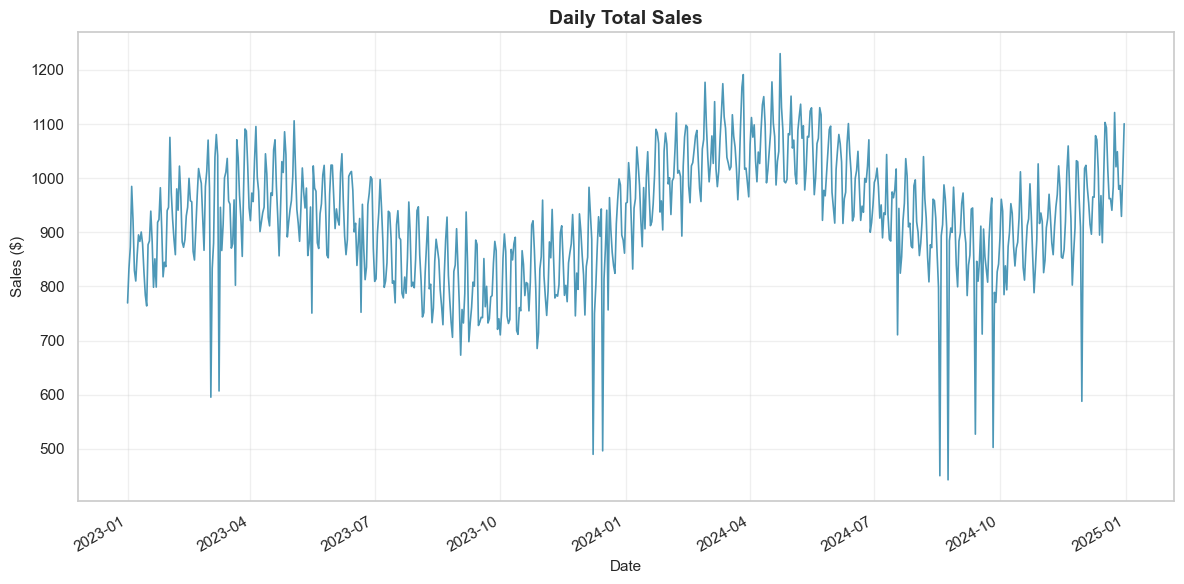

In [23]:
daily = data.groupby("Date")["Sales"].sum()
fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, color="#2E86AB", linewidth=1.2, alpha=0.85)
ax.set_title("Daily Total Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Sales ($)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("daily_sales.png", dpi=150)
plt.show()
plt.close(fig)

#### Monthly sales

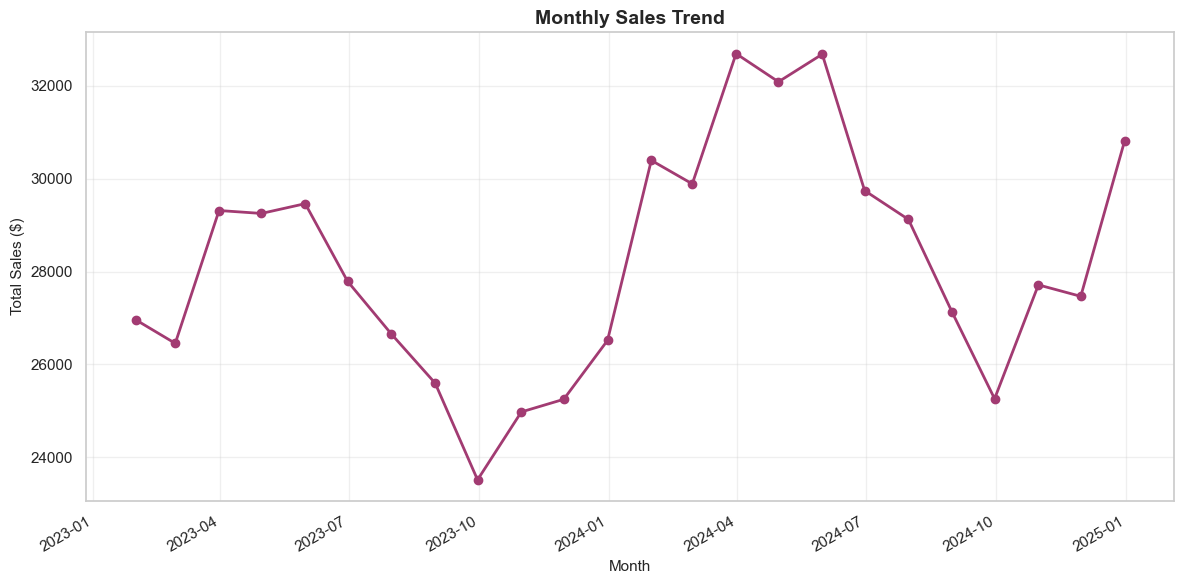

In [26]:
monthly = data.set_index("Date")["Sales"].resample("M").sum()
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, marker="o", color="#A23B72", linewidth=2)
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig('monthly_sales.png', dpi=150)
plt.show()
plt.close(fig)

#### Quarterly sales

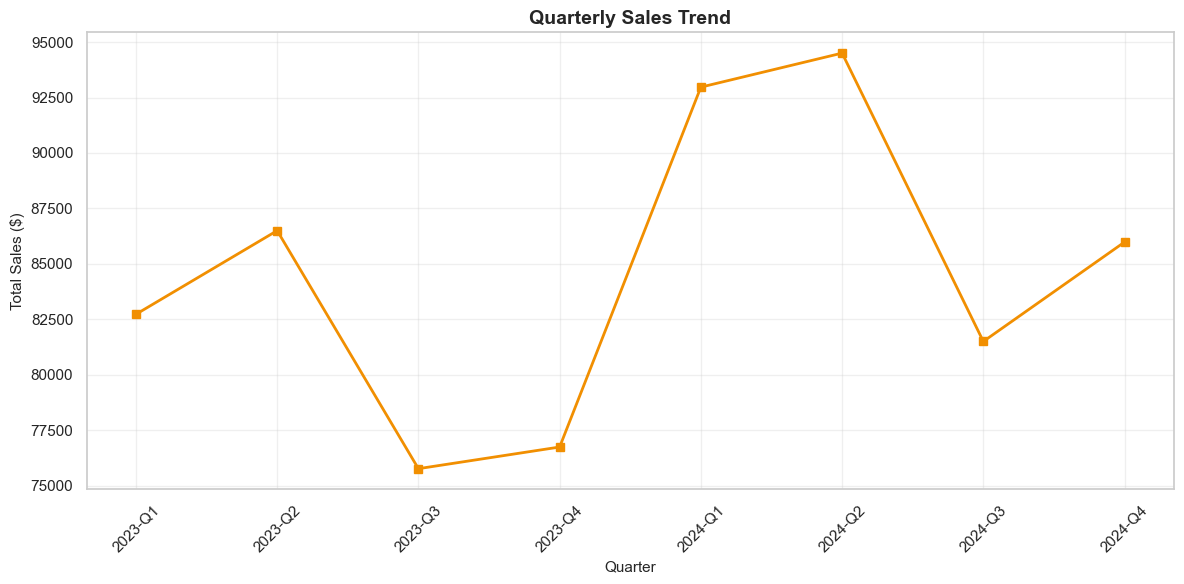

In [28]:
quarterly = data.set_index("Date")["Sales"].resample("Q").sum()

fig, ax = plt.subplots()
labels = [f"{p.year}-Q{p.quarter}" for p in quarterly.index]
ax.plot(labels, quarterly.values, marker="s", color="#F18F01", linewidth=2)
ax.set_title("Quarterly Sales Trend")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Sales ($)")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig("quarterly_sales_line_chart.png", dpi=150)
plt.show()
plt.close(fig)

### Category comparison charts

Why a bar chart?
Bar charts are good at comparing discrete, unordered categories side by side. Bar LENGTH is one of the most accurately perceived visual encodings, making it easy to rank categories and compare magnitudes precisely.

#### Total sales by category

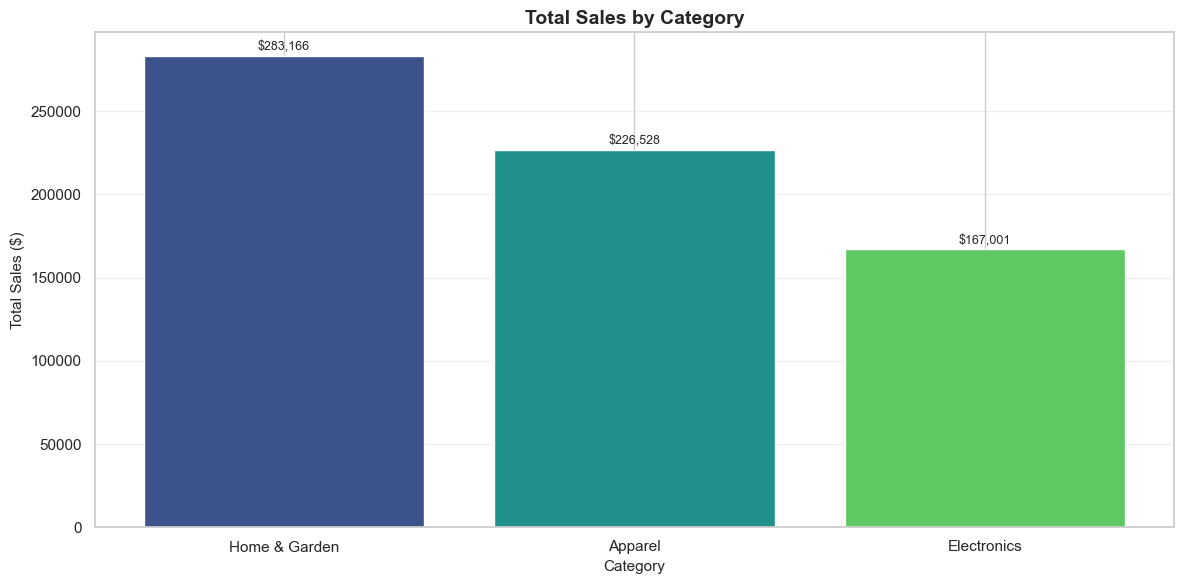

In [29]:
totals = data.groupby("Category")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
palette = sns.color_palette("viridis", len(totals))
bars = ax.bar(totals.index, totals.values, color=palette)
ax.set_title("Total Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales ($)")
ax.grid(True, axis="y", alpha=0.3)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"${height:,.0f}",xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),textcoords="offset points",ha="center",fontsize=9,)
fig.tight_layout()
fig.savefig("category_bar_chart.png", dpi=150)
plt.show()
plt.close(fig)

#### Category sales share

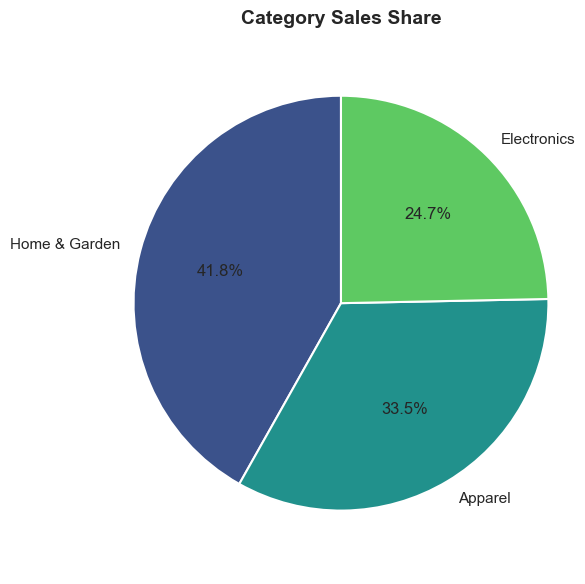

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = sns.color_palette("viridis", len(totals))
ax.pie(totals.values,labels=totals.index,
        autopct="%1.1f%%",startangle=90,colors=colors,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},)
ax.set_title("Category Sales Share")
ax.axis("equal")  # Ensures the pie is drawn as a circle
fig.tight_layout()
fig.savefig("category_pie_chart.png", dpi=150)
plt.show()
plt.close(fig)

## Chart Type Rationale:
- Line charts preserve chronological order andmake trend, seasonality, and easy to read.
- Bar chart bar length is one of the most ideal for ranking/comparing discrete categories precisely.
- Pie chart : useful ONLY for a small number of categories where the goal is to show rough proportion of a meaningful whole (100%).
- It should be avoided when there are many categories.